<a href="https://colab.research.google.com/github/winarwahyuw/data-science-250401020025-winar-wahyu-wulansari/blob/main/Data_Science_Pertemuan_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## PERTEMUAN 11
#### Nama : Winar Wahyu Wulansari
#### NIM : 250401020025
#### Kelas : IF405


Dimensi data: (300, 4)

Statistika Deskriptif:
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


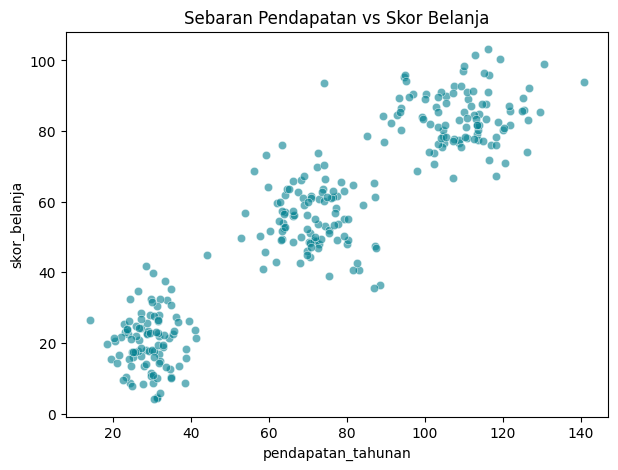

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))
data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Dimensi data:', df.shape)
print('\nStatistika Deskriptif:')
print(df.describe().round(2))

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6, color='#028090')
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

In [2]:

from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling     :', X_scaled.std(axis=0).round(3))


Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling     : [1. 1.]


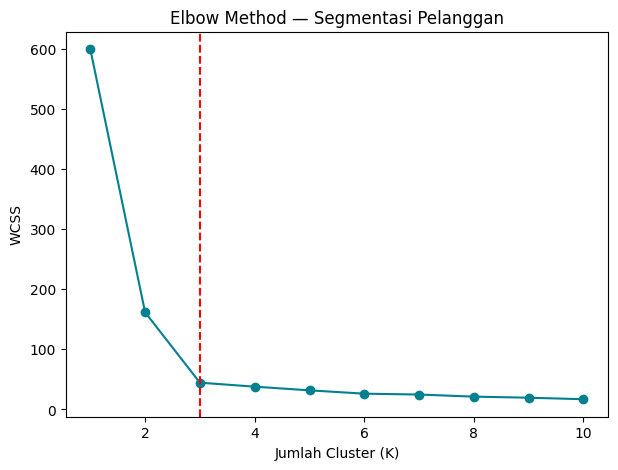

In [3]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.axvline(x=3, color='red', linestyle='--')
plt.show()


# **Interpretasi Grafik Elbow Method**



*   Titik Melandai (Titik Siku): Berdasarkan grafik di atas, penurunan nilai WCSS terlihat sangat tajam dari K=1 ke K=2, lalu mulai melandai secara signifikan tepat setelah K=3. Oleh karena itu, titik elbow atau siku optimal berada pada K=3.

*   Kesesuaian Kelompok: Hasil ini sangat sesuai dengan skenario pembuatan dataset awal di Langkah 1 yang sengaja dibuat dari gabungan 3 kelompok data tersembunyi (hemat, menengah, dan boros).

In [4]:
from sklearn.metrics import silhouette_score

model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print('\nRata-rata nilai fitur asli per cluster:')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir : 44.556
Silhouette Score: 0.695

Rata-rata nilai fitur asli per cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


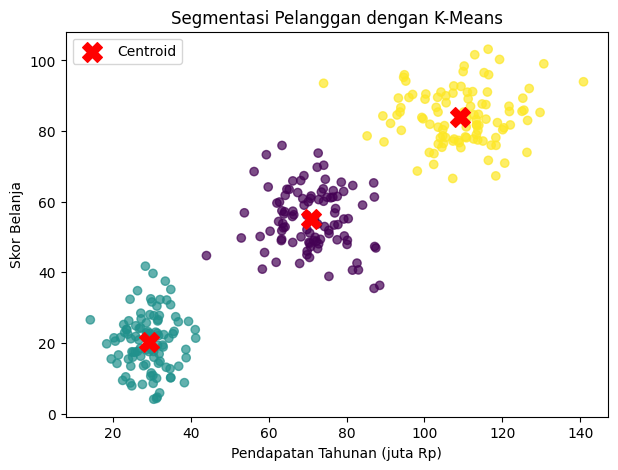

In [5]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))

plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'], c=df['cluster'], cmap='viridis', alpha=0.7)

plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroid')

plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

# **Interpretasi Karakteristik Setiap Segmen Pelanggan**
Berdasarkan hasil visualisasi sebaran grafik scatter plot di atas, kita bisa membagi perilaku konsumen ke dalam tiga kelompok utama:

* Segmen Hemat: Pelanggan dengan tingkat pendapatan tahunan cenderung rendah dan memiliki skor pengeluaran belanja yang juga rendah.
* Segmen Menengah: Pelanggan yang berada di posisi tengah, di mana tingkat pendapatan tahunan serta skor pengeluaran belanjanya rata-rata atau sedang.
* Segmen Boros / Premium: Pelanggan kelas atas dengan pendapatan tahunan tinggi serta memiliki skor pengeluaran belanja yang sangat agresif atau besar.

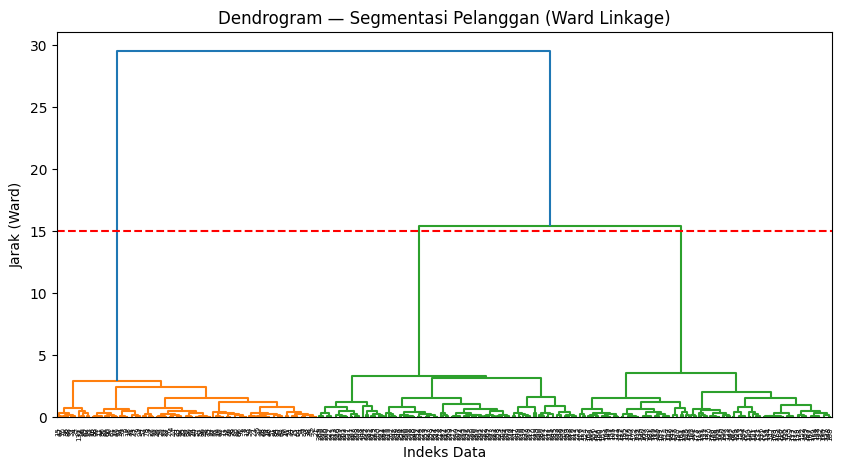

In [6]:

from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--')
plt.show()


# Kesimpulan & Interpretasi Analisis Clustering

---

### 1. Apa yang Dipelajari (Metodologi & Teknik)
* **Prapemrosesan Data (Feature Scaling):** Penggunaan `StandardScaler` sangat krusial untuk menyamakan skala fitur `pendapatan_tahunan` dan `skor_belanja` ($\mu=0, \sigma=1$). Hal ini mencegah algoritma berbobot jarak seperti K-Means didominasi oleh salah satu variabel.
* **Penentuan Jumlah Klaster Optimal ($K$):**
  * **Elbow Method:** Penurunan nilai *Within-Cluster Sum of Squares* (WCSS) mengalami tekukan/siku tajam pada $K=3$.
  * **Hierarchical Clustering (Dendrogram):** Pemotongan *Ward Linkage* pada jarak $\approx 15$ mengonfirmasi pembagian kelompok yang paling natural adalah 3 klaster.
* **Evaluasi & Interpretasi Model:** Penggunaan *Silhouette Score* untuk mengukur kerapatan dan pemisahan antarklaster, serta teknik `inverse_transform` pada *centroid* agar koordinat pusat klaster dapat dibaca kembali dalam skala nilai asli.

---

### 2. Insight Bisnis (Temuan & Implikasi Strategis)
Berdasarkan pembentukan 3 klaster pelanggan, dapat ditarik relevansi strategi bisnis sebagai berikut:

* 🟢 **Cluster 0 — Segmen Hemat:**
  * *Karakteristik:* Pendapatan tahunan rendah dan skor belanja rendah.
  * *Rekomendasi Bisnis:* Fokus pada penawaran produk bernilai hemat (*entry-level*), promo diskon bundling, dan program cicilan terjangkau.
* 🟡 **Cluster 1 — Segmen Menengah:**
  * *Karakteristik:* Pendapatan tahunan sedang dan tingkat pengeluaran/skor belanja rata-rata.
  * *Rekomendasi Bisnis:* Pertahankan retensi dengan program loyalitas, *cross-selling*, dan penawaran produk reguler.
* 🟣 **Cluster 2 — Segmen Premium / Boros:**
  * *Karakteristik:* Pendapatan tahunan tinggi dan skor belanja sangat agresif/tinggi.
  * *Rekomendasi Bisnis:* Target utama margin keuntungan tinggi. Berikan layanan VIP, akses eksklusif untuk produk edisi terbatas, serta rekomendasi personalized (*up-selling*).

---

### 3. Batasan Analisis (Limitations)
* **Penggunaan Data Sintetis:** Dataset dibentuk secara artificial menggunakan kombinasi `np.random.normal()`. Akibatnya, pemisahan kelompok terlampau rapi dan ideal jika dibandingkan dengan pola data pelanggan di dunia nyata (*real-world data*) yang umumnya memiliki banyak *noise* dan *overlap*.
* **Fitur Terbatas:** Klasterisasi baru memanfaatkan 2 variabel kontinu (`pendapatan_tahunan` dan `skor_belanja`). Variable demografi seperti `usia` dan `gender` belum diikutsertakan dalam pemodelan.
* **Karakteristik K-Means:** Algoritma ini mengasumsikan bentuk klaster bersifat cembung/sferis (*spherical*) dan sangat sensitif terhadap nilai pencilan (*outliers*).
* **Perspektif Statis:** Analisis ini hanya memotret perilaku pelanggan pada satu titik waktu (*snapshot* data) dan tidak memperhitungkan dinamika perubahan perilaku belanja dari waktu ke waktu (*time-series / longitudinal aspect*).